In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [62]:
df = pd.read_csv('../data/processed/unemployment_clean.csv', parse_dates=['Date'])
print(df.columns.tolist())
df.shape

['Region', 'Date', 'Estimated_Unemployment_Rate_(%)', 'Estimated_Employed', 'Estimated_Labour_Participation_Rate_(%)', 'Area']


(740, 6)

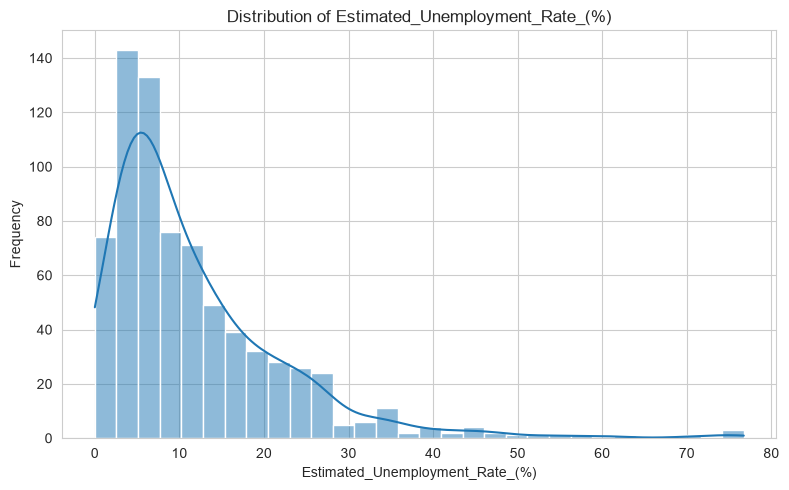

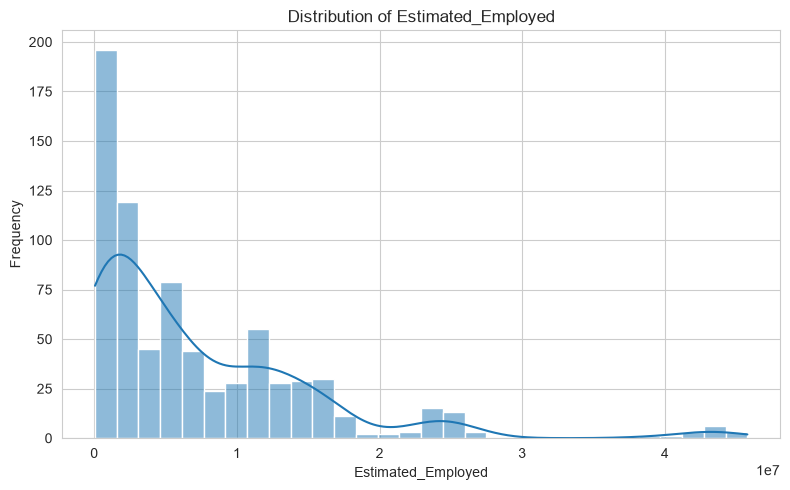

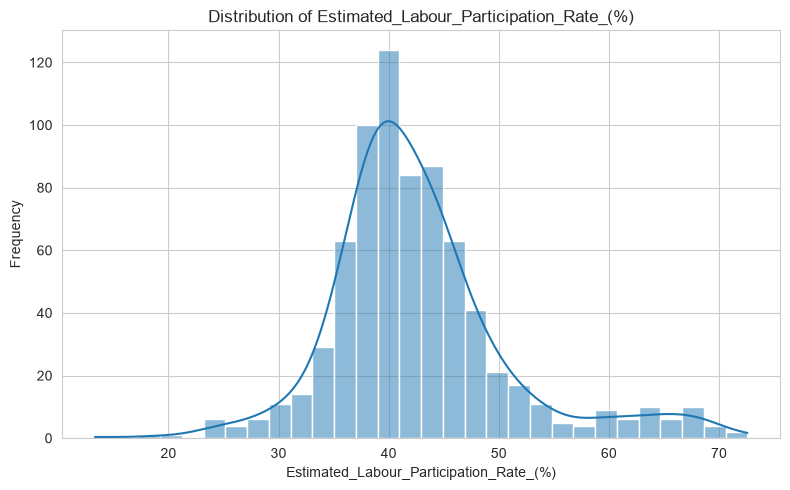

In [63]:
sns.set_style('whitegrid')
numeric_cols = df.select_dtypes(include='float').columns
counts = 1

for col in numeric_cols:   
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, bins=30, kde=True)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(f'../images/0{counts}_distribution_of_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()
    counts += 1



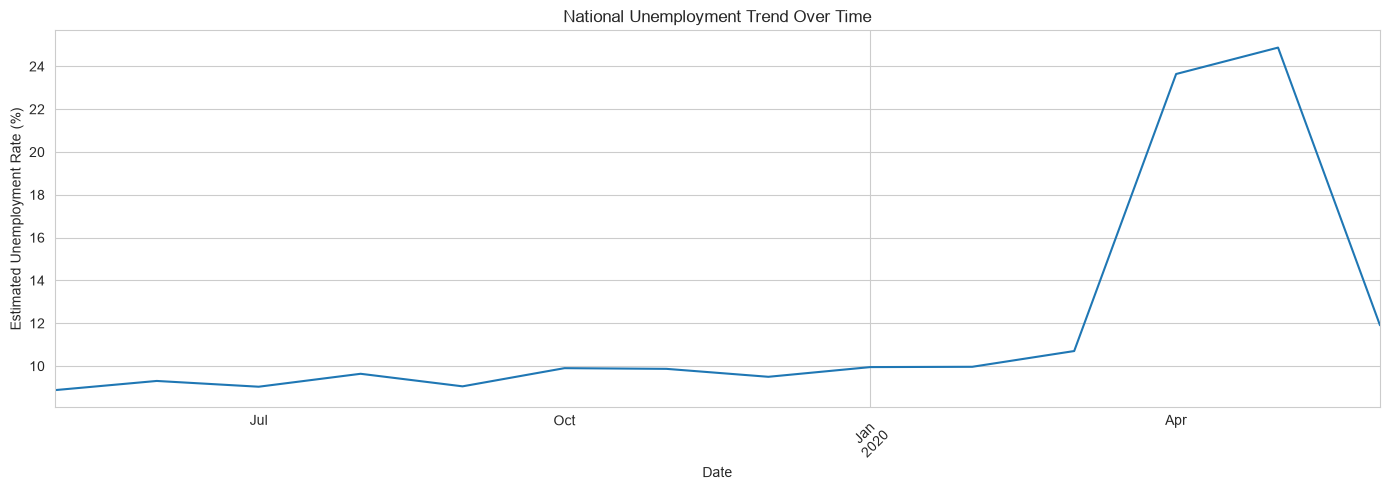

In [64]:
national_unemployment = df.groupby('Date')['Estimated_Unemployment_Rate_(%)'].mean()

national_unemployment.plot(figsize=(14, 5))

plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('National Unemployment Trend Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('../images/04_national_unemployment.png', dpi=150, bbox_inches='tight')

plt.show()


**Note on the national average:** this is a simple mean across regions per date,
which treats every region equally regardless of how completely it was reported.
Chandigarh (12 rows) and Sikkim (17 rows) contribute the same weight per date as
fully-reported regions (28 rows) — the incomplete reporting flagged in cleaning
means this national figure isn't a true population-weighted or fully-complete
average. Treat it as a directional trend, not a precise national statistic.

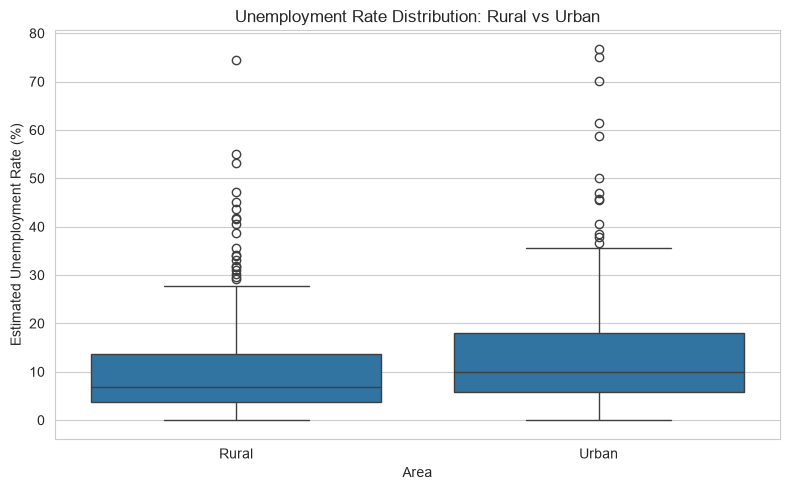

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Area',
    y='Estimated_Unemployment_Rate_(%)'
)

plt.xlabel('Area')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate Distribution: Rural vs Urban')
plt.tight_layout()
plt.savefig('../images/05_unemployment_rate_distribution(rural_vs_urban).png', dpi=150, bbox_inches='tight')

plt.show()

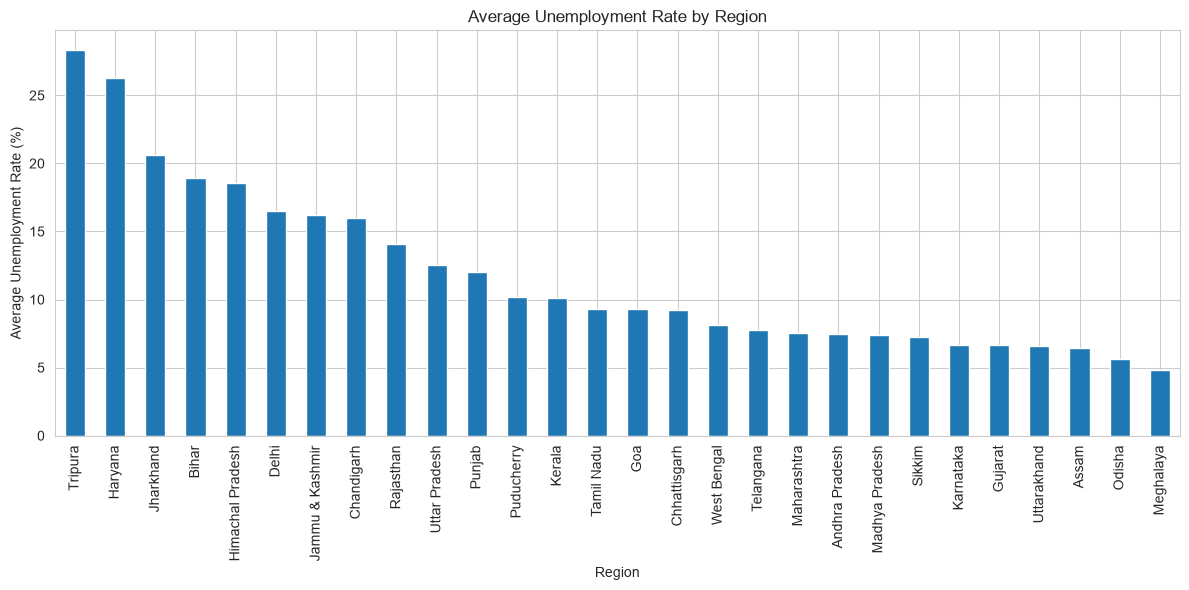

In [66]:
regional_rate = df.groupby('Region')['Estimated_Unemployment_Rate_(%)'].mean().sort_values(ascending=False)
regional_rate.plot(kind='bar', figsize=(12, 6))

plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate by Region')

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig('../images/06_average_unemployment_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

**Note on data-sparse regions:** Chandigarh, Sikkim, Jammu & Kashmir, and Goa
have incomplete Rural/Urban reporting (see 02_data_cleaning.ipynb). If any of
these appear at the extremes of this ranking, that could reflect which months/
areas were actually reported rather than a genuine standout unemployment level.

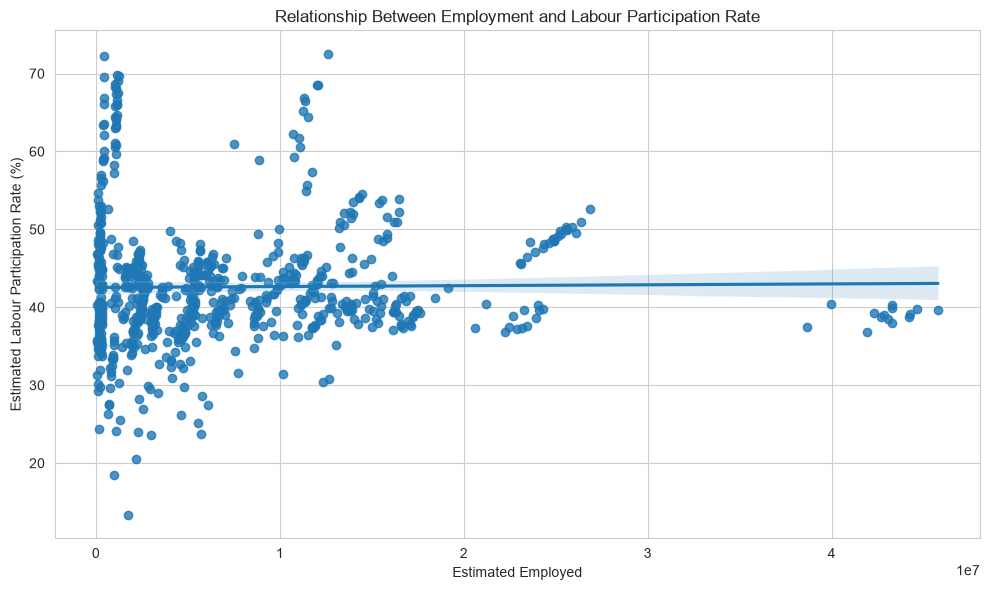

Correlation between Employed and Labour Participation Rate: 0.011


In [67]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Estimated_Employed',
    y='Estimated_Labour_Participation_Rate_(%)'
)

plt.xlabel('Estimated Employed')
plt.ylabel('Estimated Labour Participation Rate (%)')
plt.title('Relationship Between Employment and Labour Participation Rate')

plt.grid(True)
plt.tight_layout()
plt.savefig('../images/07_employment_vs_labour.png', dpi=150, bbox_inches='tight')
plt.show()


corr = df['Estimated_Employed'].corr(
    df['Estimated_Labour_Participation_Rate_(%)']
)

print(f'Correlation between Employed and Labour Participation Rate: {corr:.3f}')

**Why this correlation is near zero (0.011):** Estimated_Employed is a raw
headcount that scales with each region's population size, while Labour
Participation Rate is a population-independent percentage. Comparing the two
directly across regions of very different sizes isn't an apples-to-apples
comparison — the near-zero correlation reflects that mismatch, not an absence
of any real relationship between employment and participation within a region.

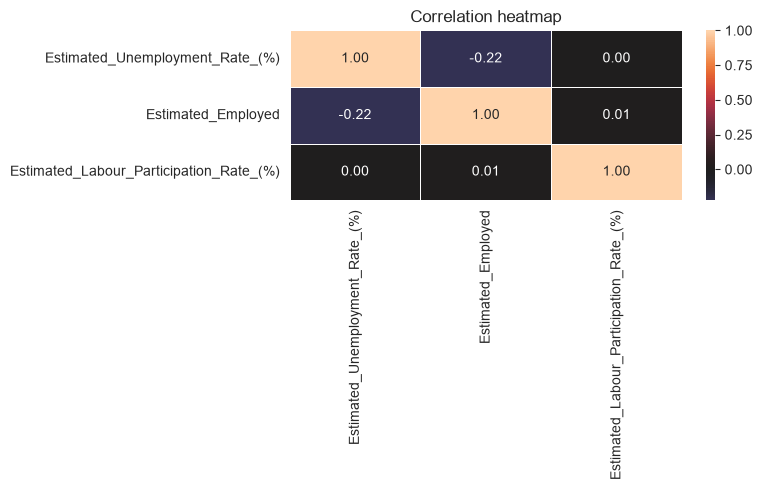

In [68]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    center=0,
    linewidths=0.5
)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../images/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings from EDA

### Distributions
- Estimated Unemployment Rate: mean 11.79%, median 8.35%, heavily right-skewed —
  75% of all readings are below 15.89%, but the max reaches 76.74% (Puducherry,
  April 2020, already flagged in data understanding)
- Estimated Employed: mean 7.20M, median 4.74M, also right-skewed and spanning a
  huge range (49,420 to 45.78M) — expected, since this mixes small UTs with
  India's largest states
- Estimated Labour Participation Rate: mean 42.63%, median 41.16%, much more
  symmetric than the other two — range 13.33% to 72.57%

### National trend over time
Unemployment rate is stable (~9-10%) from May 2019 through February 2020, then
spikes sharply to ~23-25% by April/May 2020 before beginning to fall back by
June 2020 — a clean, visible COVID-lockdown signature at the national level.
(Caveat: this is an unweighted mean across regions with uneven reporting
completeness — see note in notebook.)

### Rural vs Urban
Urban areas show a consistently higher median unemployment rate than Rural
(~10% vs ~6-7%), with a higher and slightly wider interquartile range as well.
Both areas show a long tail of extreme outliers above 70%, tracing back to the
same April 2020 lockdown spike — Urban's most extreme outliers (~76-77%) are
marginally higher than Rural's (~74%), consistent with the Puducherry finding
from data understanding, where both areas were hit hard but Urban slightly more so.

### Regional comparison
Average unemployment rate varies substantially by region (see bar chart) — some
data-sparse regions (Chandigarh, Sikkim, J&K, Goa) appear near the extremes,
which may partly reflect incomplete reporting rather than a genuine standout
rate (see caveat in notebook).

### Correlations
- Unemployment Rate vs Employed: -0.22 (weak negative — higher unemployment
  rate loosely associated with lower employed counts, though this is diluted
  by the population-size differences across regions)
- Unemployment Rate vs Participation Rate: 0.00 (no linear relationship at the
  aggregate level)
- Employed vs Participation Rate: 0.01 (essentially zero — expected, since
  Employed is a population-scaled headcount and Participation Rate is a
  population-independent percentage; not a meaningful comparison across
  regions of very different sizes)

### Next step
COVID-19 impact analysis — quantify the before/after lockdown shift precisely,
identify which regions were hit hardest and by how much, and examine whether
Rural and Urban areas were affected differently.